In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [4]:
# Add the ../ so it can find the data folder from the notebooks folder
df = pd.read_excel('../data/raw/online_retail_II.xlsx', engine='openpyxl')
print(f"Dataset Shape: {df.shape}")
df.head(10)

Dataset Shape: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [5]:
print(f"Date Range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Unique Customers: {df['Customer ID'].nunique()}")
print(f"Unique Products: {df['StockCode'].nunique()}")
print(f"Countries: {df['Country'].nunique()}")

Date Range: 2009-12-01 07:45:00 to 2010-12-09 20:01:00
Unique Customers: 4383
Unique Products: 4632
Countries: 40


In [6]:
print("Missing Values:\n", df.isnull().sum())
miss_pct = (df['Customer ID'].isnull().sum() / len(df)) * 100
print(f"Missing CustomerID %: {miss_pct:.2f}%")
print(f"Duplicate Invoices: {df.duplicated(subset=['Invoice']).sum()}")

Missing Values:
 Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64
Missing CustomerID %: 20.54%
Duplicate Invoices: 496645


In [7]:
print("Quantity Distribution:\n", df['Quantity'].describe())
neg_q = (df['Quantity'] < 0).sum()
print(f"Negative Quantities (Returns): {neg_q}")
print(f"Price Stats: Min={df['Price'].min()}, Max={df['Price'].max()}, Median={df['Price'].median()}")

Quantity Distribution:
 count    525461.000000
mean         10.337667
std         107.424110
min       -9600.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       19152.000000
Name: Quantity, dtype: float64
Negative Quantities (Returns): 12326
Price Stats: Min=-53594.36, Max=25111.09, Median=2.1


In [8]:
cancellations = df['Invoice'].astype(str).str.startswith('C').sum()
print(f"Cancellations (Invoice starts with 'C'): {cancellations}")
zero_price = (df['Price'] <= 0).sum()
print(f"Zero/Negative Prices: {zero_price}")
print("Extremely high quantities:", df['Quantity'].max())

Cancellations (Invoice starts with 'C'): 10206
Zero/Negative Prices: 3690
Extremely high quantities: 19152


In [9]:
import os
import json

# 1. Create the directory structure explicitly for Colab
# This creates data/raw/ inside the current folder
os.makedirs('data/raw', exist_ok=True)

data_quality_summary = {
    'total_rows': len(df),
    'total_columns': len(df.columns),
    'missing_values': df.isnull().sum().to_dict(),
    'duplicate_rows': int(df.duplicated().sum()),
    'date_range': {
        'start': str(df['InvoiceDate'].min()),
        'end': str(df['InvoiceDate'].max())
    },
    'negative_quantities': int((df['Quantity'] < 0).sum()),
    'cancelled_invoices': int(df['Invoice'].astype(str).str.startswith('C').sum()),
    'missing_customer_ids': int(df['Customer ID'].isnull().sum()),
    'missing_customer_ids_percentage': round((df['Customer ID'].isnull().sum() / len(df)) * 100, 2)
}

# 2. Use the local path 'data/raw/...' instead of '../data/raw/...'
# Because in Colab, you are already in the root directory.
file_path = '../data/raw/data_quality_summary.json'

with open(file_path, 'w') as f:
    json.dump(data_quality_summary, f, indent=4)

print(f"✅ JSON Summary Generated at: {file_path}")

✅ JSON Summary Generated at: ../data/raw/data_quality_summary.json


Revenue by Month (Line Chart)

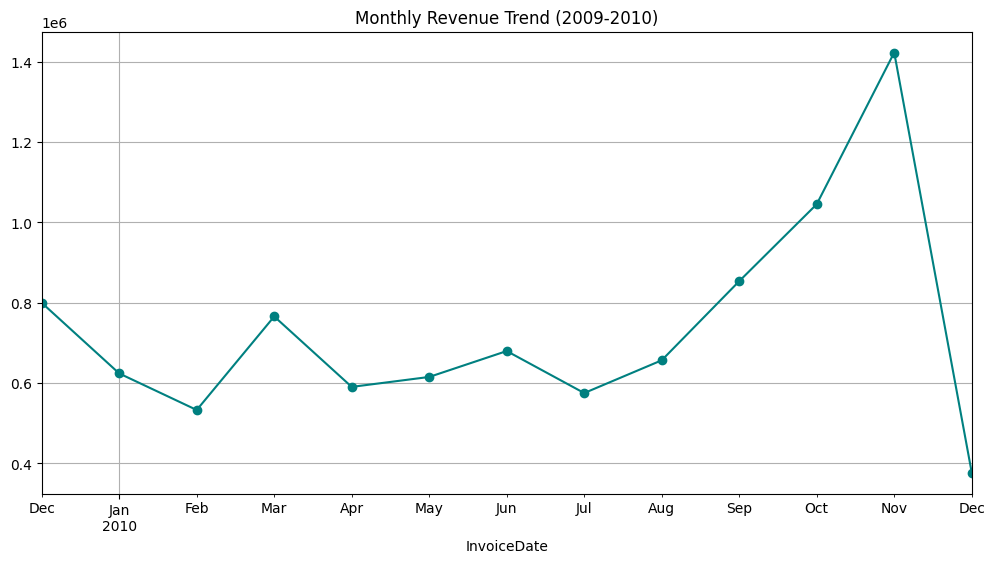

In [10]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalRevenue'] = df['Quantity'] * df['Price']
plt.figure(figsize=(12, 6))
df.set_index('InvoiceDate').resample('M')['TotalRevenue'].sum().plot(kind='line', marker='o', color='teal')
plt.title('Monthly Revenue Trend (2009-2010)')
plt.grid(True)
plt.show()

Top 10 Countries (Bar Chart)

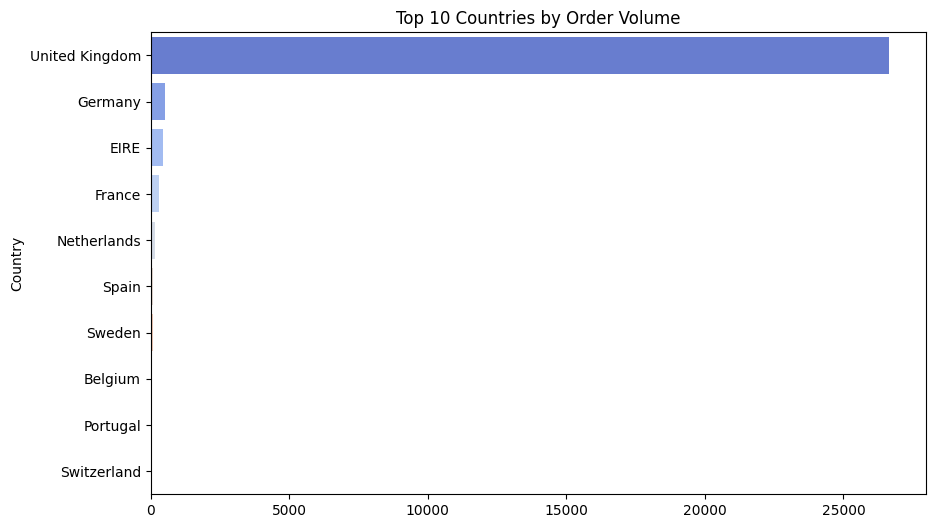

In [11]:
plt.figure(figsize=(10, 6))
top_countries = df.groupby('Country')['Invoice'].nunique().sort_values(ascending=False).head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='coolwarm')
plt.title('Top 10 Countries by Order Volume')
plt.show()

Order Hour Distribution

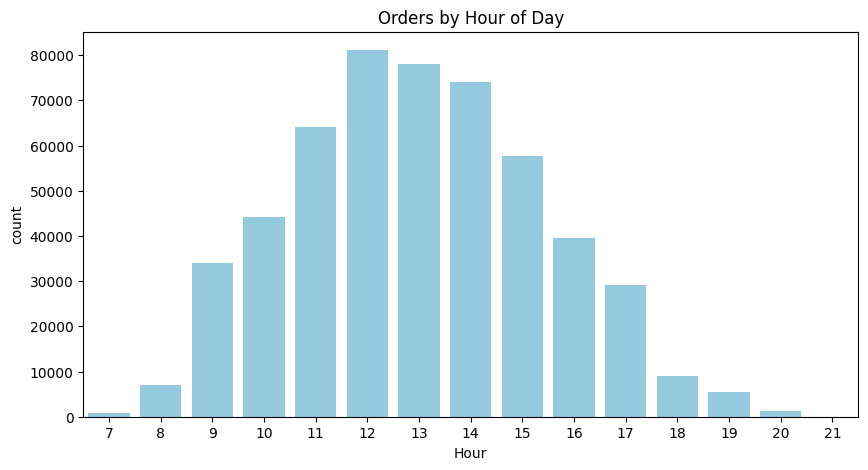

In [12]:
plt.figure(figsize=(10, 5))
df['Hour'] = df['InvoiceDate'].dt.hour
sns.countplot(data=df, x='Hour', color='skyblue')
plt.title('Orders by Hour of Day')
plt.show()

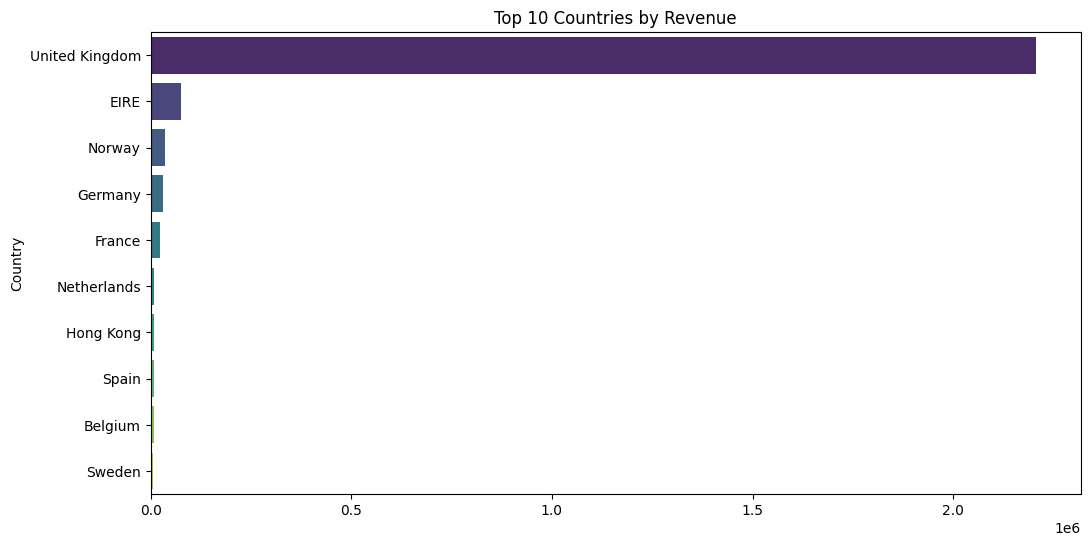

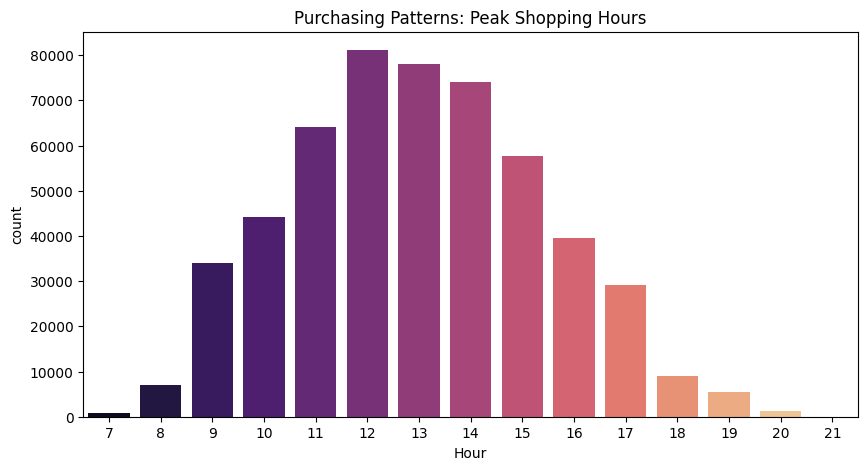

In [13]:
# Cell 12: Top 10 Countries by Revenue
plt.figure(figsize=(12,6))
top_countries = df.groupby('Country')['Price'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Revenue')
plt.show()

# Cell 13: Hourly Sales Pattern (Crucial for Business Insights)
df['Hour'] = pd.to_datetime(df['InvoiceDate']).dt.hour
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Hour', palette='magma')
plt.title('Purchasing Patterns: Peak Shopping Hours')
plt.show()

In [14]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalRevenue'] = df['Quantity'] * df['Price']

Top 10 Products by Revenue (Bar Chart)

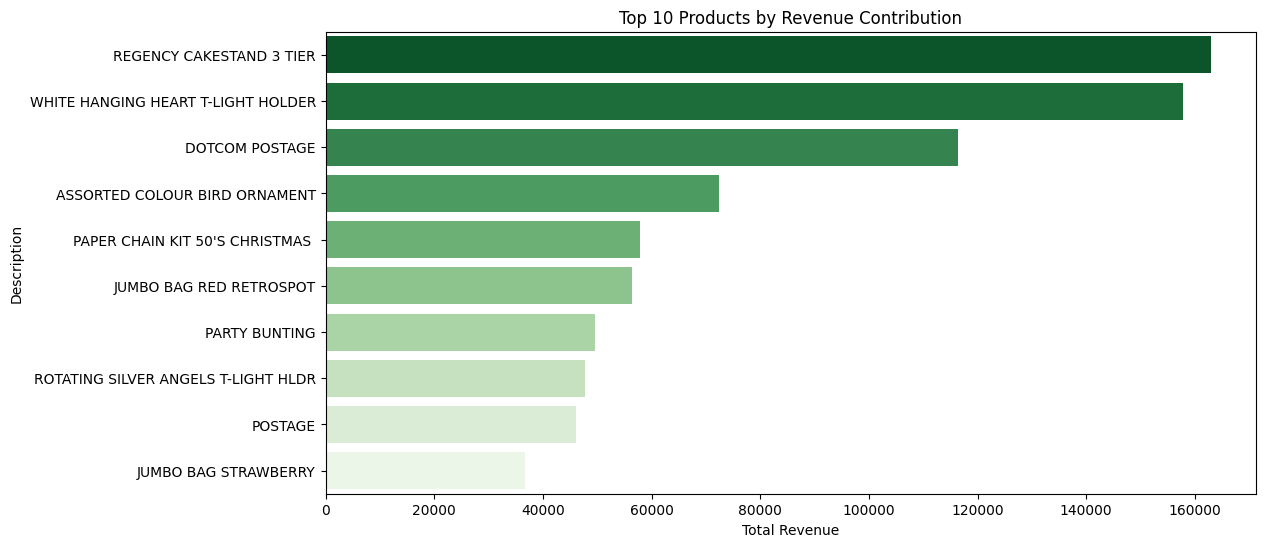

In [15]:
plt.figure(figsize=(12, 6))
top_rev_products = df.groupby('Description')['TotalRevenue'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_rev_products.values, y=top_rev_products.index, palette='Greens_r')
plt.title('Top 10 Products by Revenue Contribution')
plt.xlabel('Total Revenue')
plt.show()

Average Order Value (AOV) Distribution (Histogram)

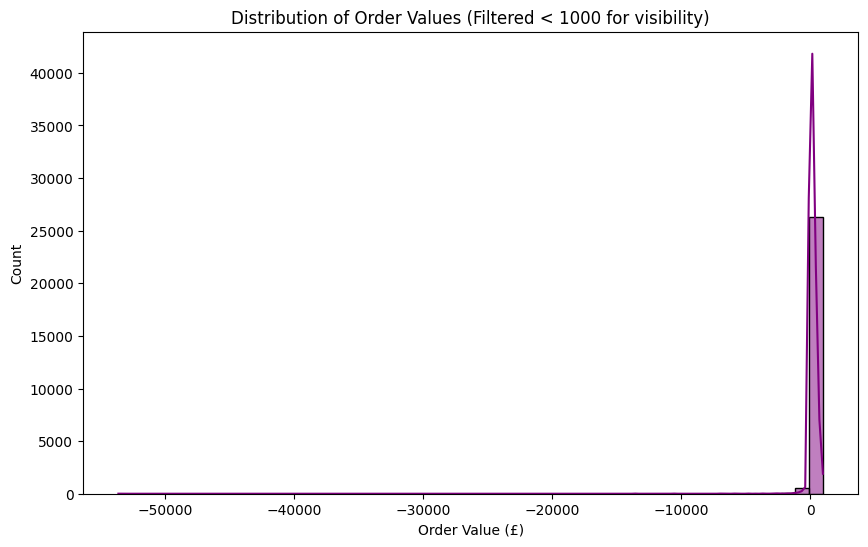

In [16]:
order_values = df.groupby('Invoice')['TotalRevenue'].sum()
plt.figure(figsize=(10, 6))
sns.histplot(order_values[order_values < 1000], bins=50, kde=True, color='purple')
plt.title('Distribution of Order Values (Filtered < 1000 for visibility)')
plt.xlabel('Order Value (£)')
plt.show()

Sales by Day of the Week (Bar Chart)

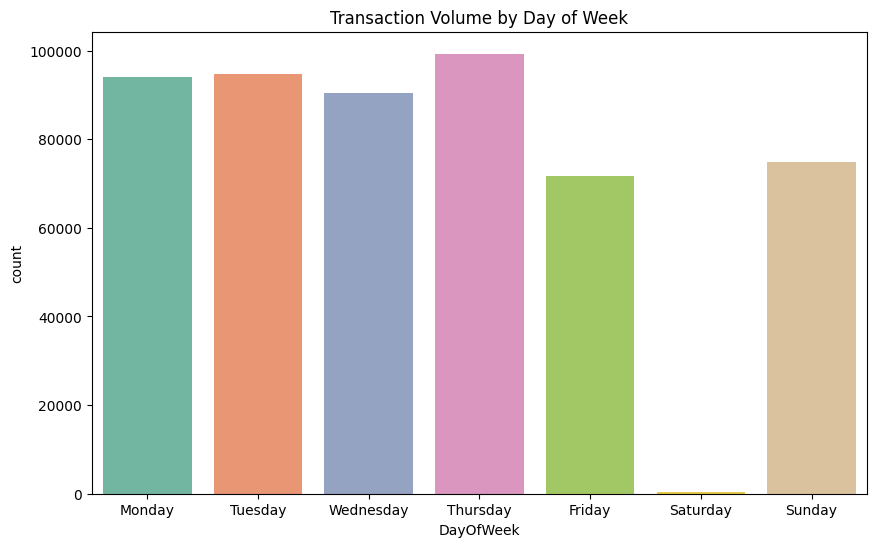

In [17]:
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='DayOfWeek', order=days_order, palette='Set2')
plt.title('Transaction Volume by Day of Week')
plt.show()

Customer Retention Rate (Pie Chart)

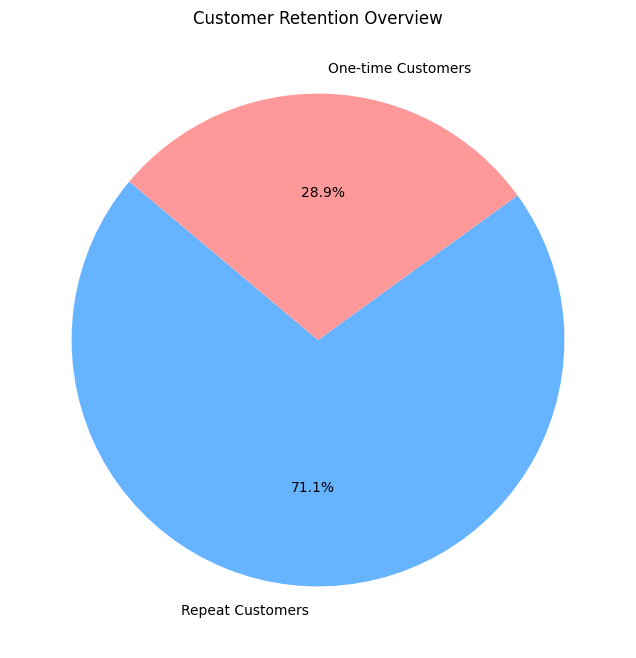

In [18]:
# Calculating simplified retention: Customers with > 1 invoice vs single-purchase customers
customer_freq = df.groupby('Customer ID')['Invoice'].nunique()
repeat_customers = (customer_freq > 1).sum()
single_customers = (customer_freq == 1).sum()

plt.figure(figsize=(8, 8))
plt.pie([repeat_customers, single_customers], labels=['Repeat Customers', 'One-time Customers'], 
        autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=140)
plt.title('Customer Retention Overview')
plt.show()

Quantity vs. Price Relationship (Scatter Plot)

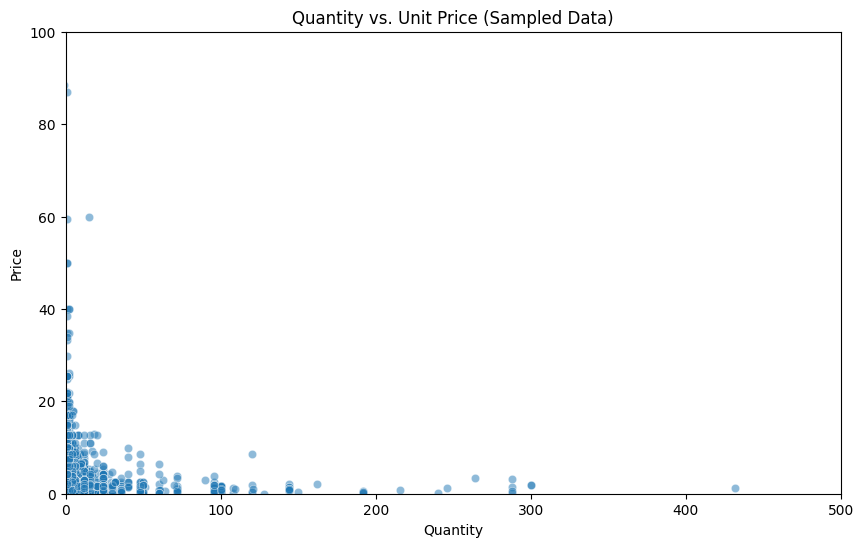

In [19]:
plt.figure(figsize=(10, 6))
# Sampling 5000 points so the graph isn't too crowded
sample_df = df.sample(5000) if len(df) > 5000 else df
sns.scatterplot(data=sample_df, x='Quantity', y='Price', alpha=0.5)
plt.title('Quantity vs. Unit Price (Sampled Data)')
plt.ylim(0, 100) # Zooming in on typical prices
plt.xlim(0, 500) # Zooming in on typical quantities
plt.show()

Monthly Transaction Count (Line Chart)

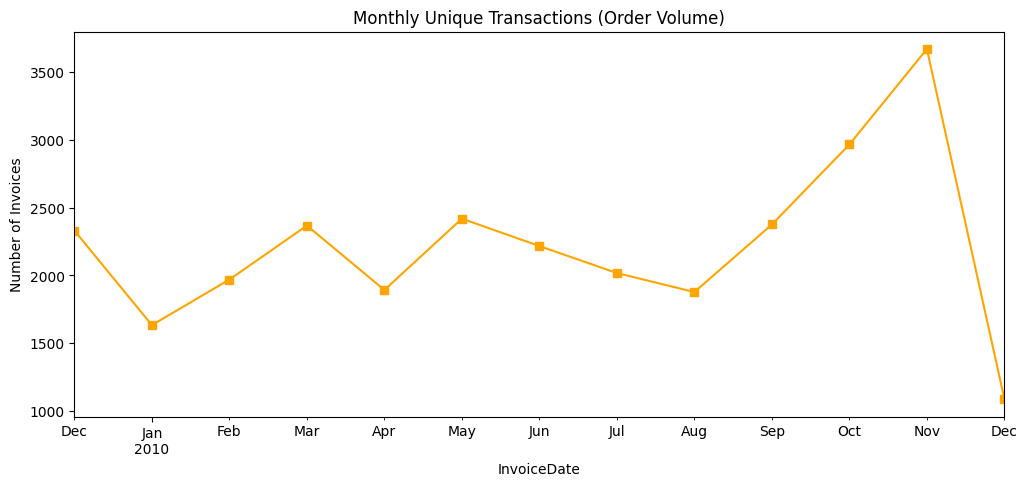

In [20]:
plt.figure(figsize=(12, 5))
df.set_index('InvoiceDate').resample('M')['Invoice'].nunique().plot(color='orange', marker='s')
plt.title('Monthly Unique Transactions (Order Volume)')
plt.ylabel('Number of Invoices')
plt.show()

Sales Distribution excluding UK (To see other markets)

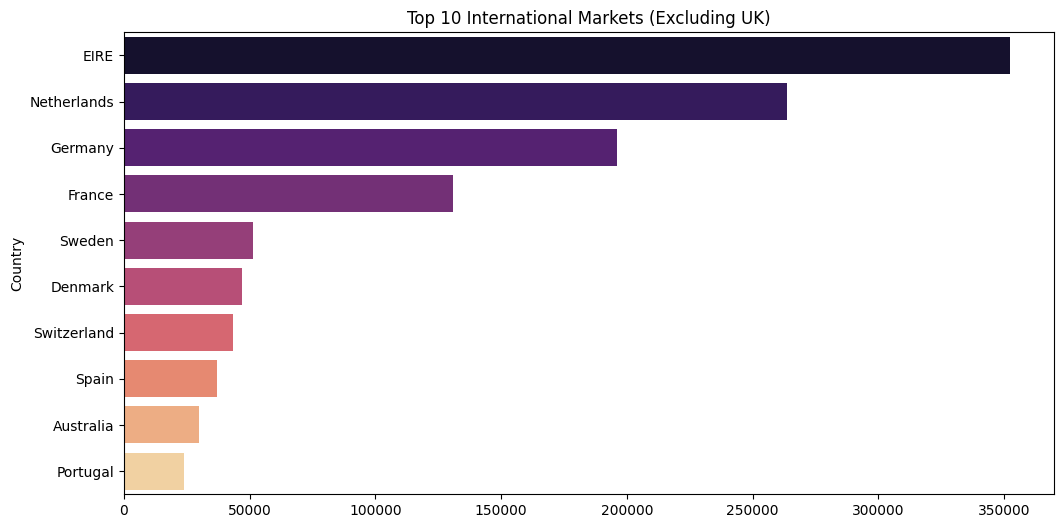

In [21]:
plt.figure(figsize=(12, 6))
non_uk_sales = df[df['Country'] != 'United Kingdom'].groupby('Country')['TotalRevenue'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=non_uk_sales.values, y=non_uk_sales.index, palette='magma')
plt.title('Top 10 International Markets (Excluding UK)')
plt.show()

Unit Price Distribution (Box Plot)

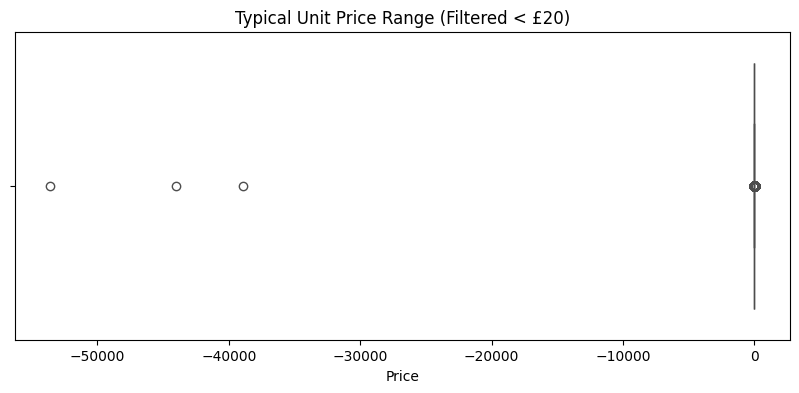

In [22]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df[df['Price'] < 20]['Price'], color='cyan')
plt.title('Typical Unit Price Range (Filtered < £20)')
plt.show()

Cumulative Revenue Over Time (Area Chart)

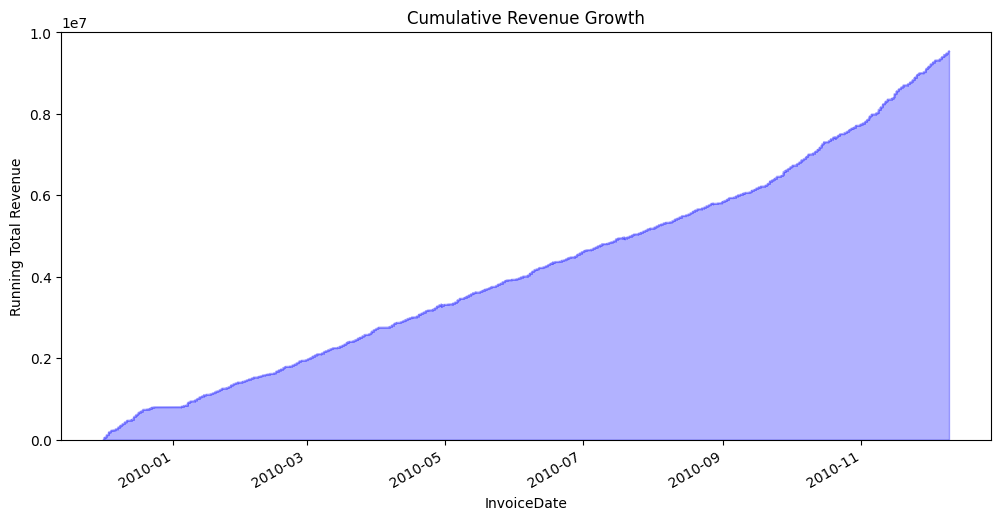

In [23]:
cumulative_rev = df.set_index('InvoiceDate')['TotalRevenue'].sort_index().cumsum()
plt.figure(figsize=(12, 6))
cumulative_rev.plot(kind='area', alpha=0.3, color='blue')
plt.title('Cumulative Revenue Growth')
plt.ylabel('Running Total Revenue')
plt.show()

Average Quantity per Invoice (Monthly)

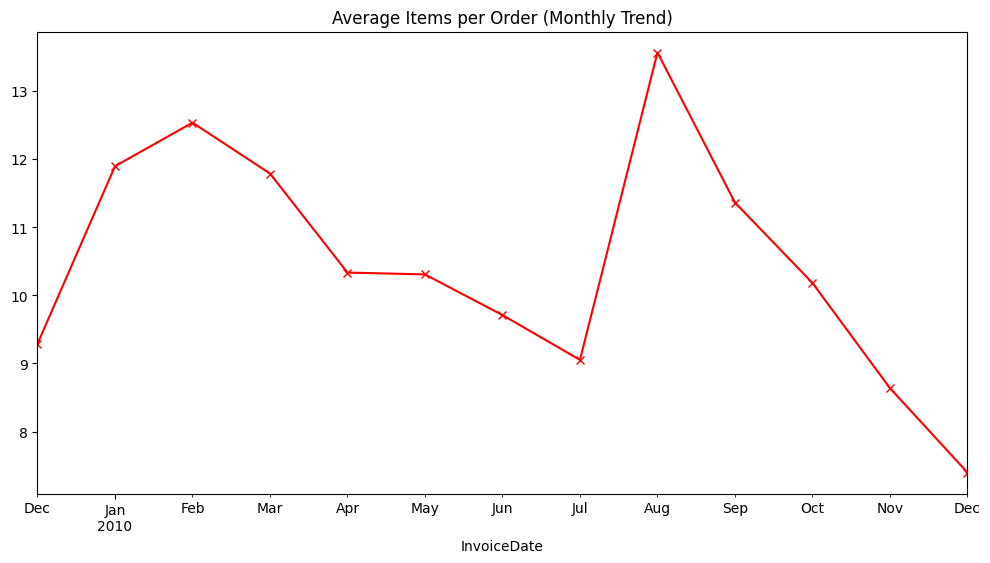

In [24]:
plt.figure(figsize=(12, 6))
df.set_index('InvoiceDate').resample('M')['Quantity'].mean().plot(marker='x', color='red')
plt.title('Average Items per Order (Monthly Trend)')
plt.show()

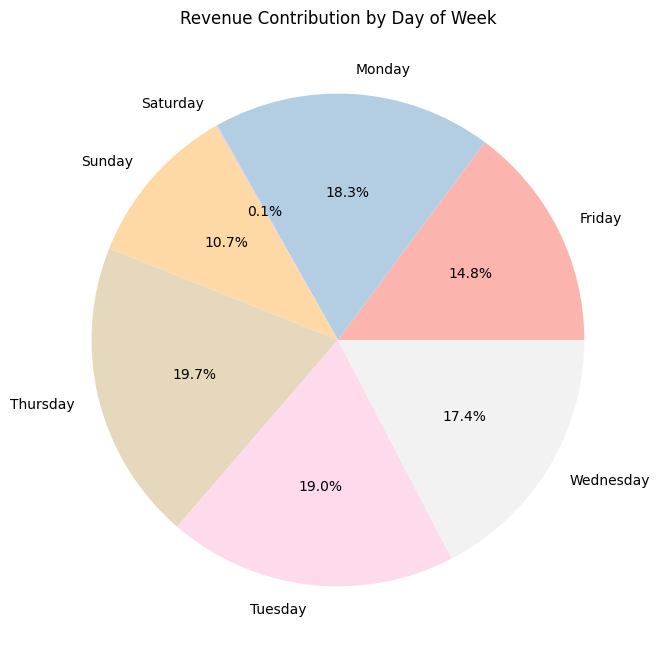

In [25]:
rev_by_day = df.groupby('DayOfWeek')['TotalRevenue'].sum()
plt.figure(figsize=(8, 8))
rev_by_day.plot(kind='pie', autopct='%1.1f%%', cmap='Pastel1')
plt.title('Revenue Contribution by Day of Week')
plt.ylabel('')
plt.show()

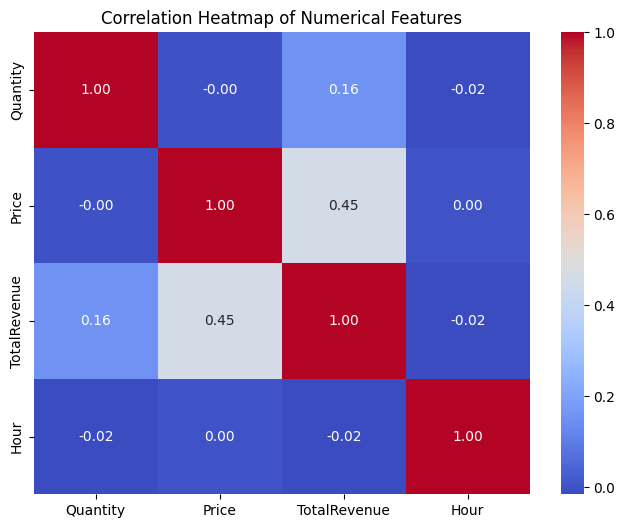

In [26]:
plt.figure(figsize=(8, 6))
# Only numeric columns
corr = df[['Quantity', 'Price', 'TotalRevenue', 'Hour']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()